In [1]:
from trees.causal_forest import parameter_tuning
from trees.topk import *

# Cross-Validation

cv (int, cross-validation generator or an iterable, default 2) Determines the cross-validation splitting strategy. Possible inputs for cv are:

- None, to use the default 3-fold cross-validation,

- integer, to specify the number of folds.

- CV splitter

- An iterable yielding (train, test) splits as arrays of indices.

For integer/None inputs, if the treatment is discrete StratifiedKFold is used, else, KFold is used (with a random shuffle in either case).

Unless an iterable is used, we call split(X,T) to generate the splits.


100%|██████████| 5/5 [01:48<00:00, 21.67s/it]


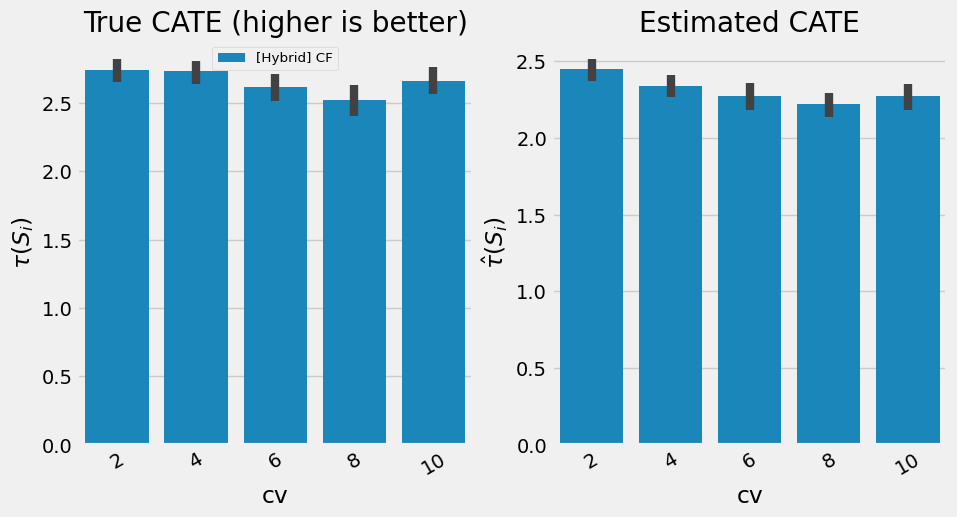

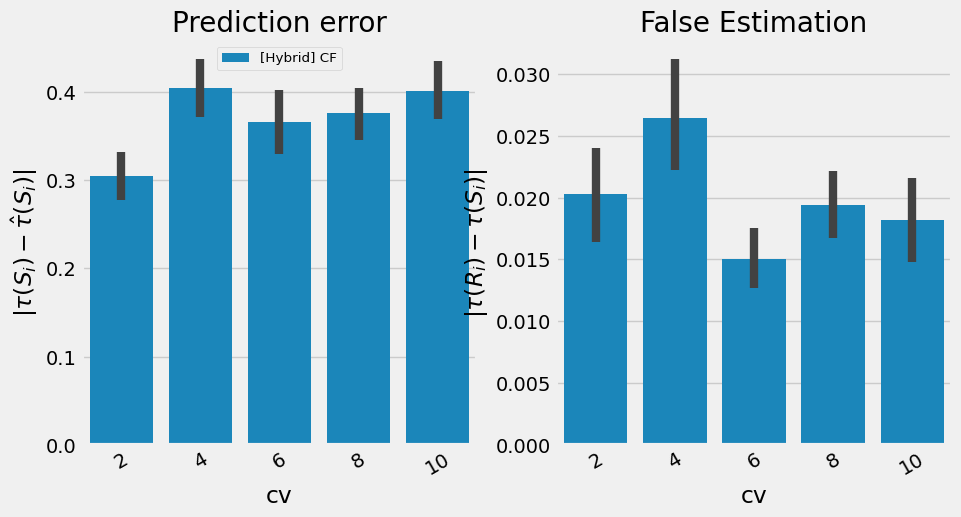

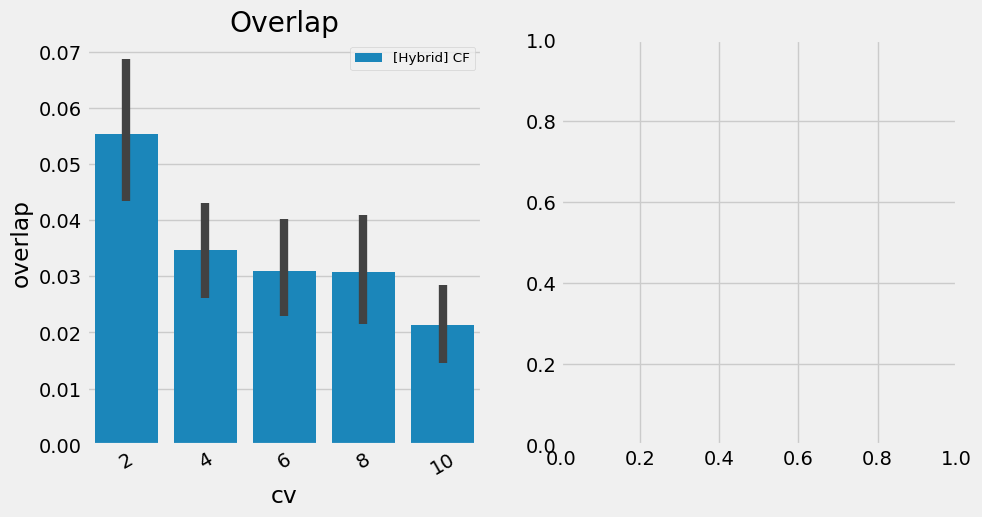

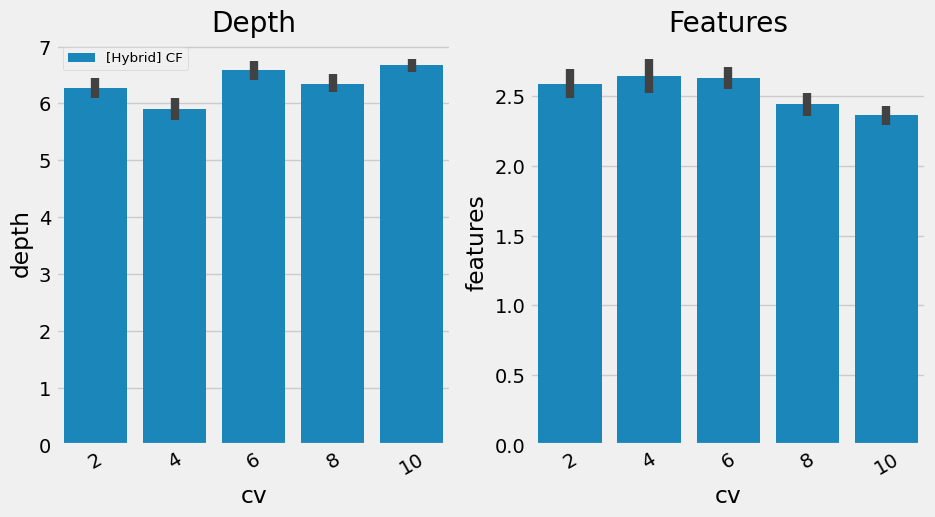

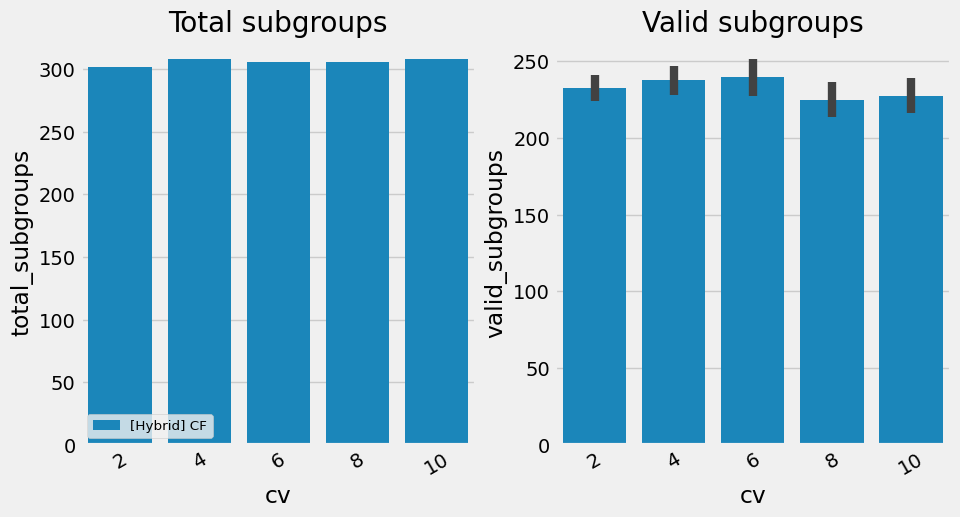

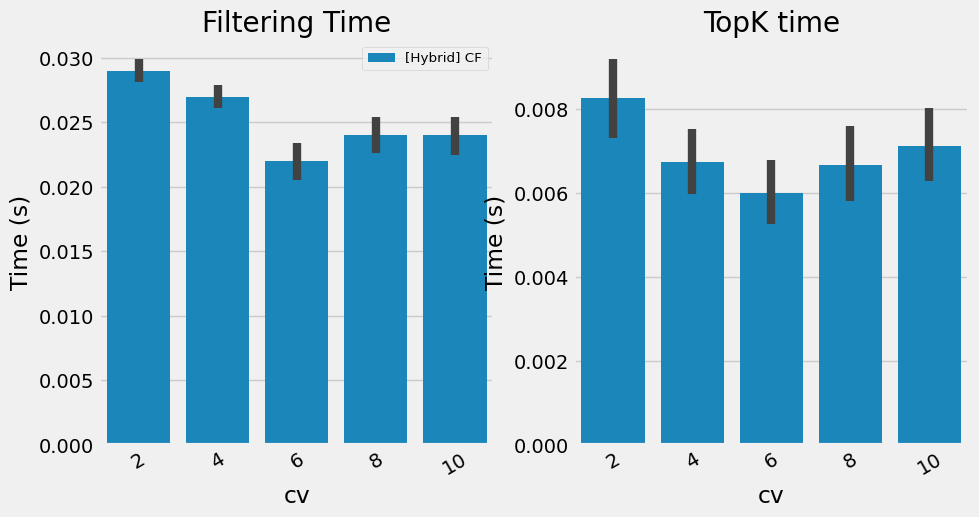

In [2]:
parameter_tuning("cv", [2, 4, 6 ,8 , 10], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Tuned vs not tuned
Whether to tune the hyperparameters of the model or not.

If tuned is True, the following function is called:

> tune(Y, T, *, X=None, W=None, sample_weight=None, groups=None, params='auto')

Tunes the major hyperparameters of the final stage causal forest based on out-of-sample R-score performance. It trains small forests of size 100 trees on a grid of parameters and tests the out of sample R-score. After the function is called, then all parameters of self have been set to the optimal hyperparameters found. The estimator however remains un-fitted, so you need to call fit afterwards to fit the estimator with the chosen hyperparameters. The list of tunable parameters can be accessed via the property tunable_params.

If tuned is False, the model uses the pre-defined models for Y and T, along with the default parameters:
> model_t=RandomForestClassifier()

> model_y=WeightedLassoCVWrapper()

100%|██████████| 2/2 [00:24<00:00, 12.29s/it]


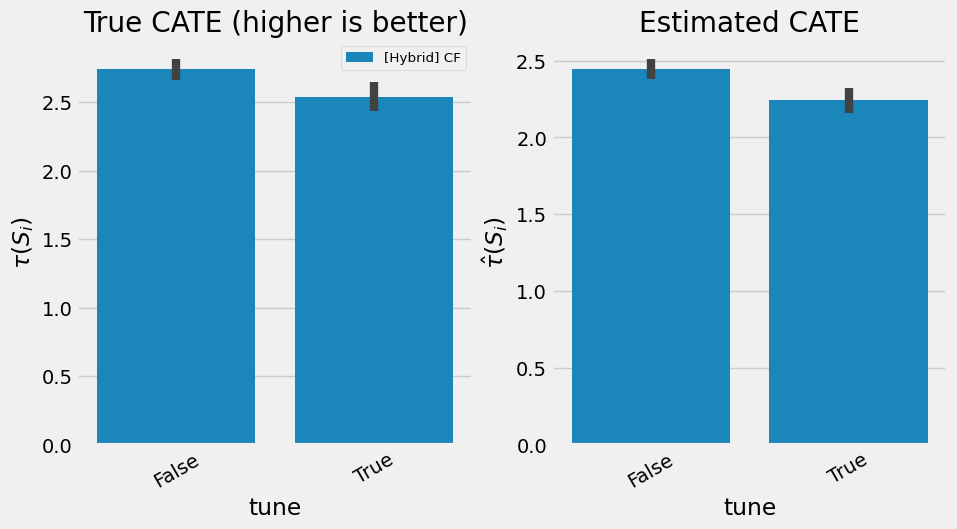

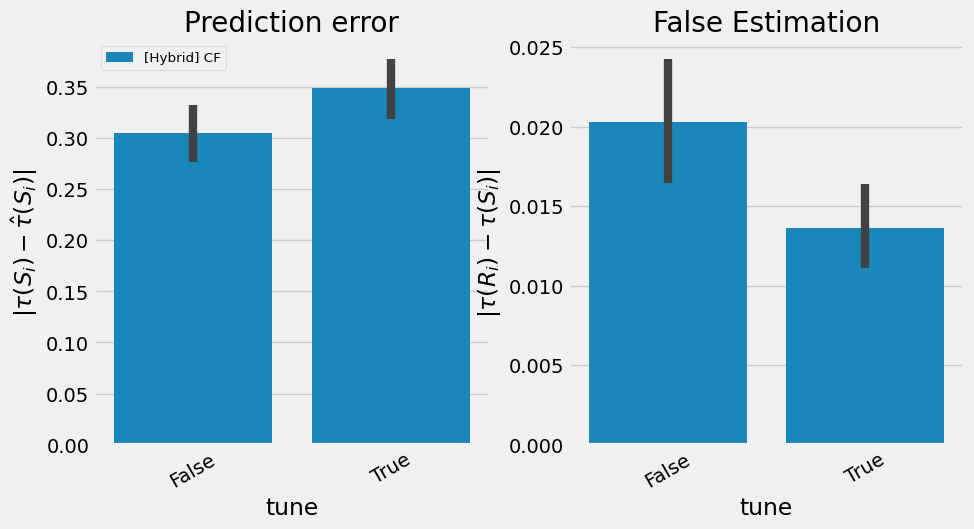

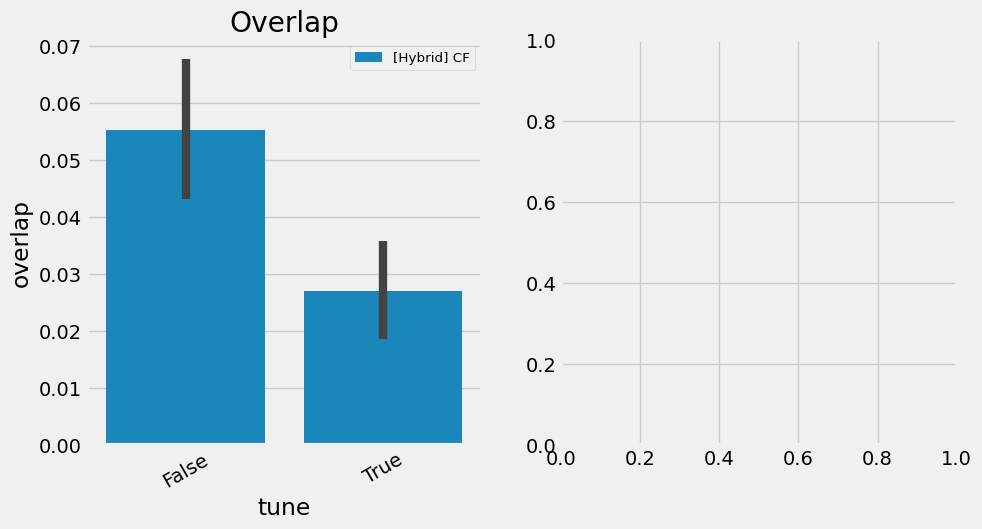

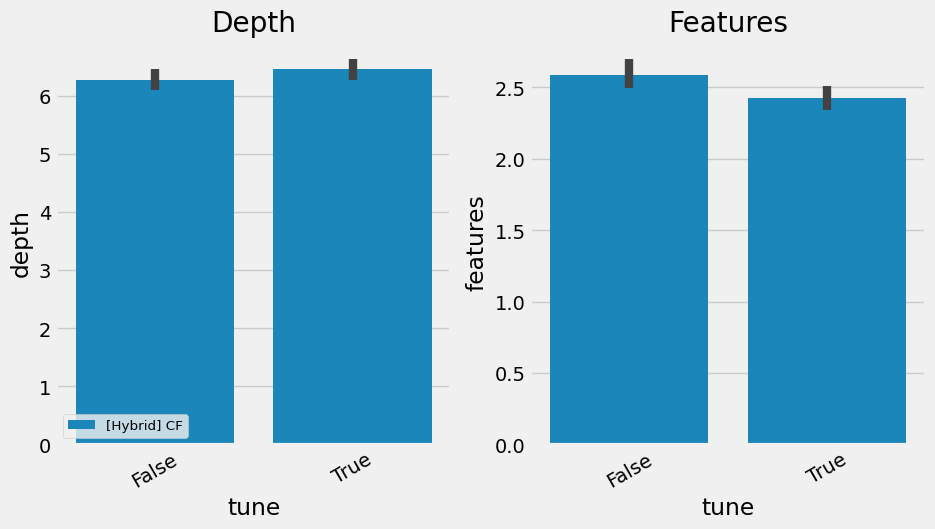

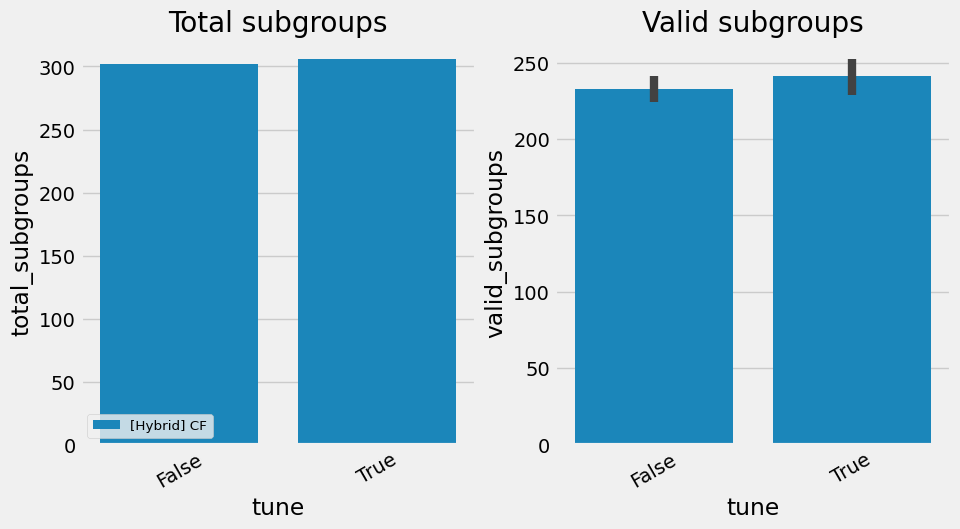

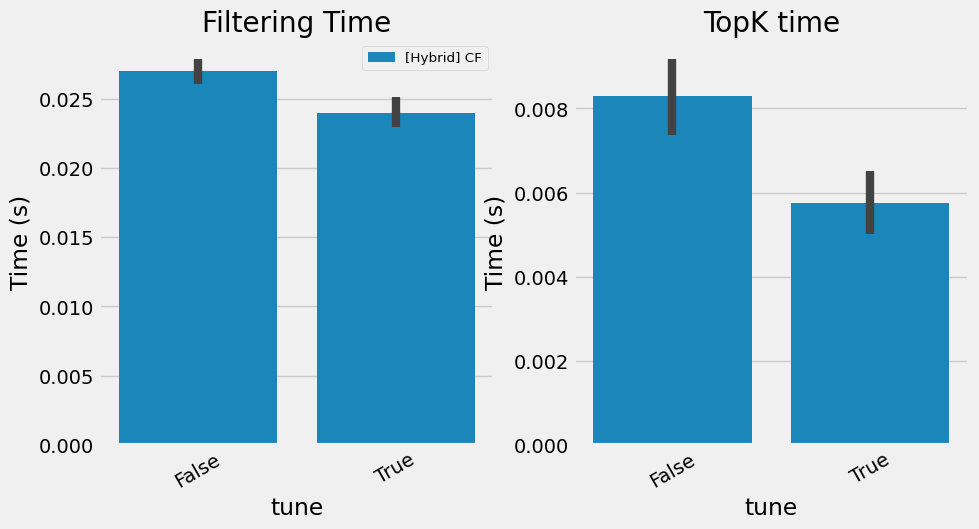

In [3]:
parameter_tuning("tune", [True, False], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Criterion (mse vs het)

criterion ({"mse", "het"}, default “mse”) – The function to measure the quality of a split. Supported criteria are "mse" for the mean squared error in a linear moment estimation tree and "het" for heterogeneity score.

The "mse" criterion finds splits that minimize the score

$sum_{child} E[(Y - <theta(child), T> - beta(child))^2 | X=child] weight(child)$

Internally, for the case of more than two treatments or for the case of two treatments with fit_intercept=True then this criterion is approximated by computationally simpler variants for computational purposes. In particular, it is replaced by:

$sum_{child} weight(child) * rho(child).T @ E[(T;1) @ (T;1).T | X in child] @ rho(child)$

where:

$rho(child) := E[(T;1) @ (T;1).T | X in parent]^{-1}
                * E[(Y - <theta(x), T> - beta(x)) (T;1) | X in child]$

This can be thought as a heterogeneity inducing score, but putting more weight on scores with a large minimum eigenvalue of the child jacobian $E[(T;1) @ (T;1).T | X in child]$, which leads to smaller variance of the estimate and stronger identification of the parameters.

The “het” criterion finds splits that maximize the pure parameter heterogeneity score

$sum_{child} weight(child) * rho(child)[:n_T].T @ rho(child)[:n_T]$
This can be thought as an approximation to the ideal heterogeneity score:

$weight(left) * weight(right) || theta(left) - theta(right)||_2^2 / weight(parent)^2$
as outlined in [cfdml1]

100%|██████████| 2/2 [00:17<00:00,  8.57s/it]


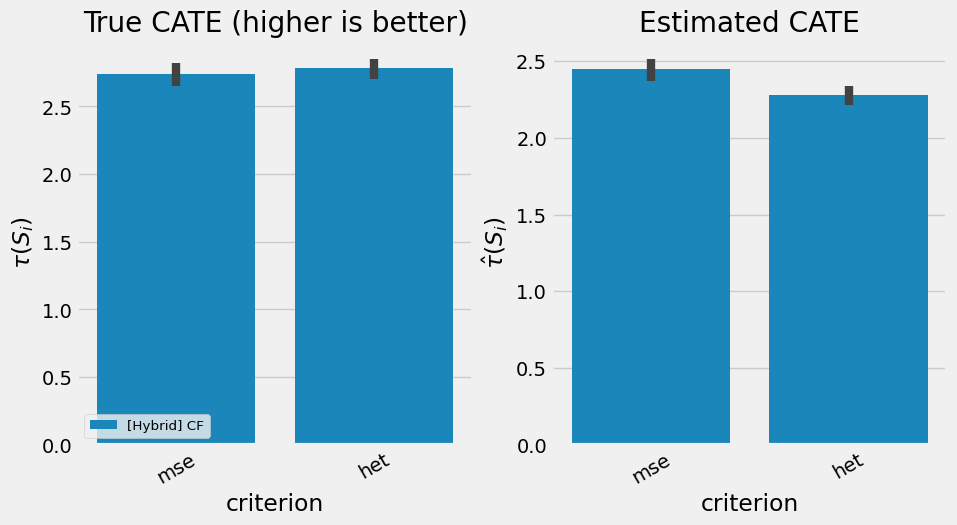

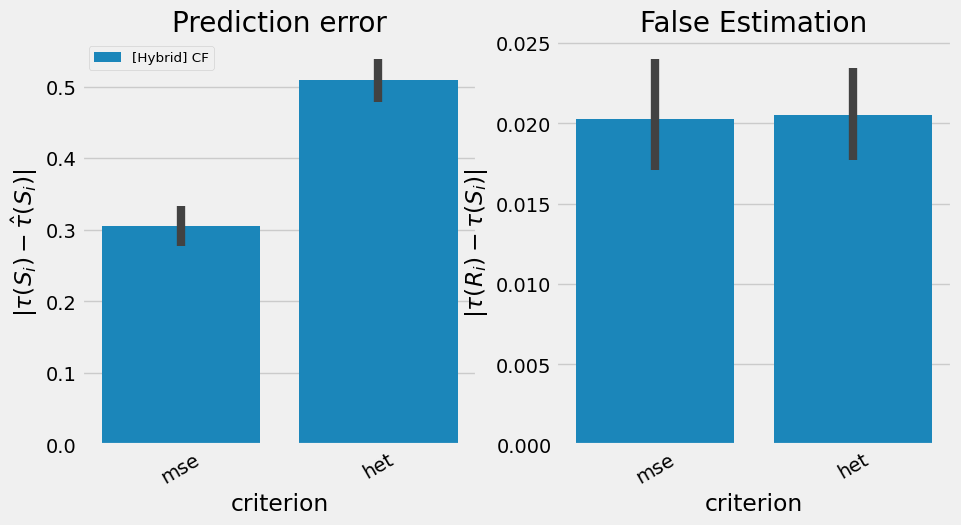

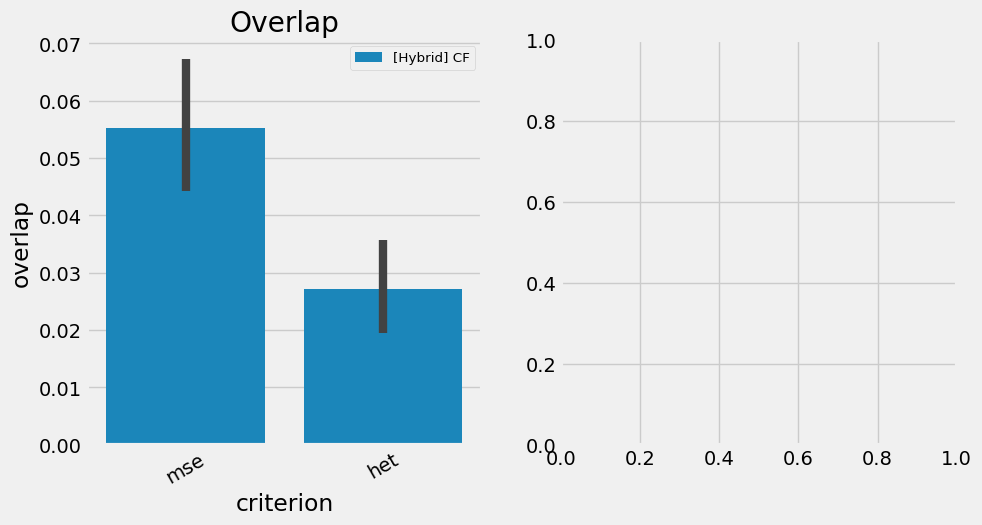

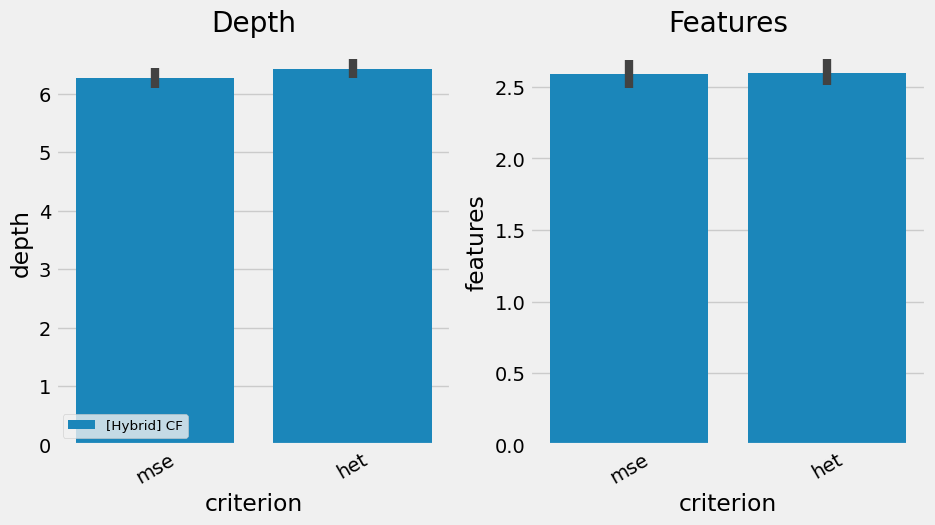

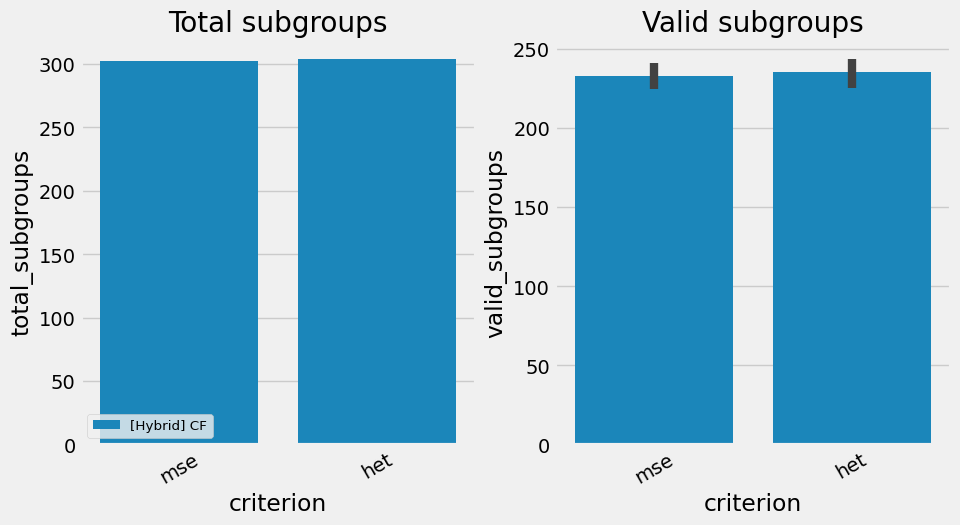

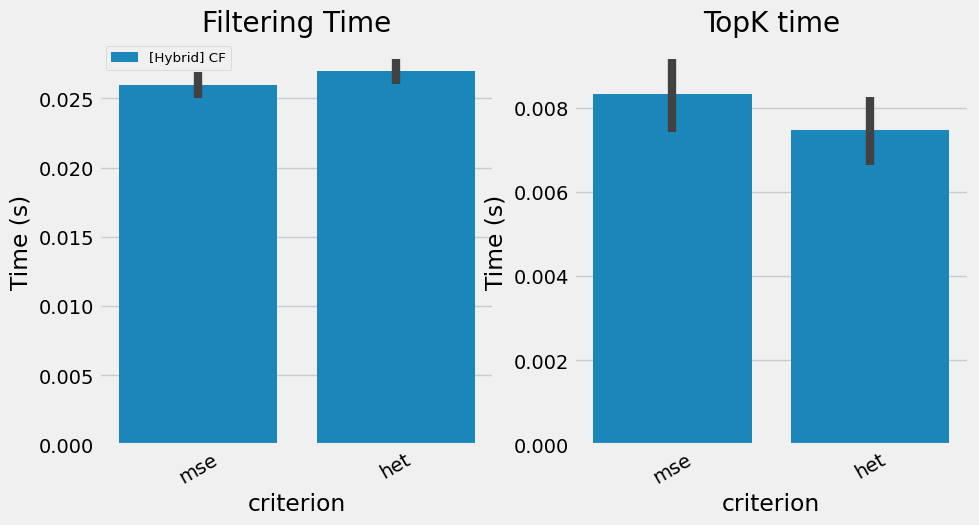

In [4]:
parameter_tuning("criterion", ["mse","het"], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Number of trees
n_estimators (int, default 100)

100%|██████████| 5/5 [00:47<00:00,  9.41s/it]


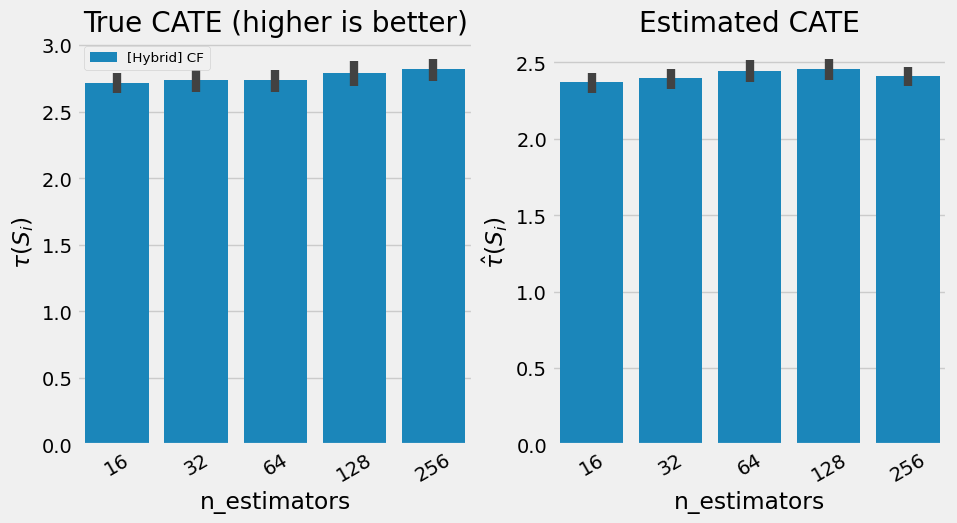

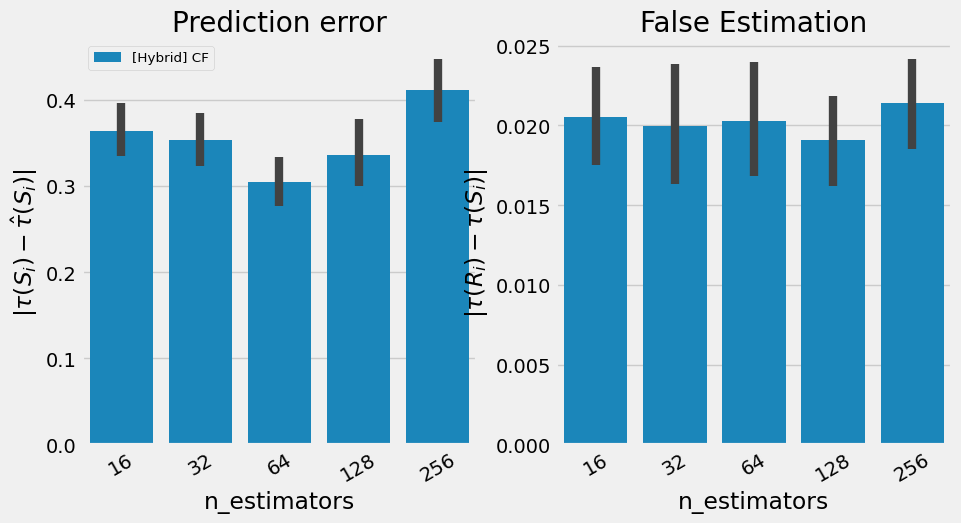

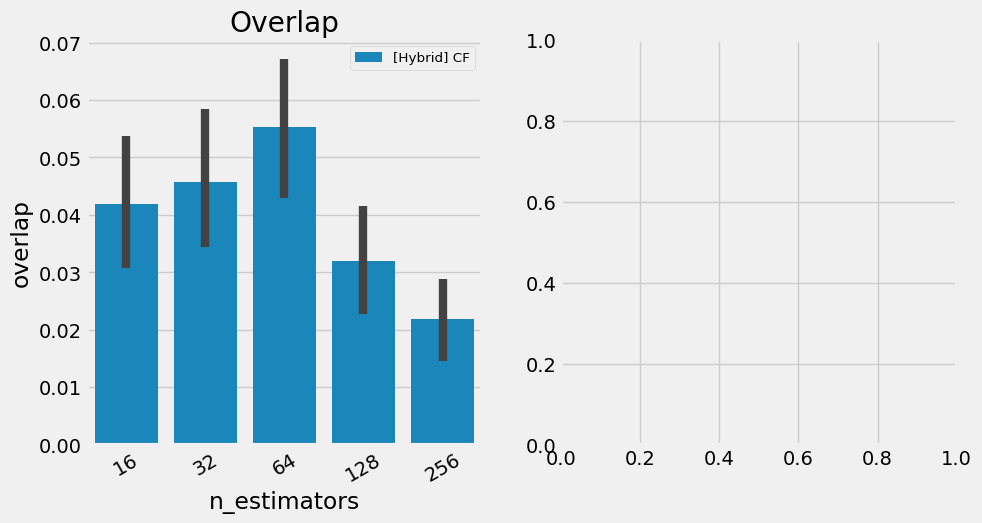

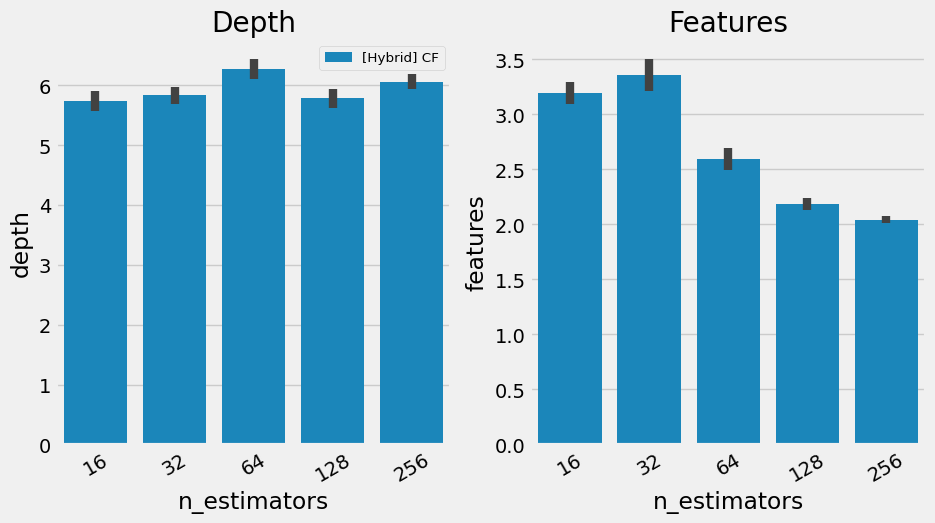

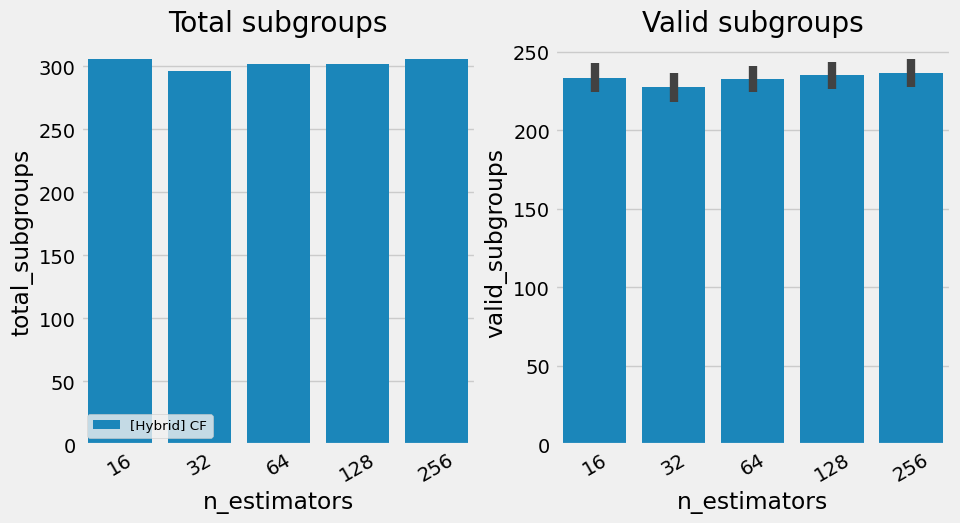

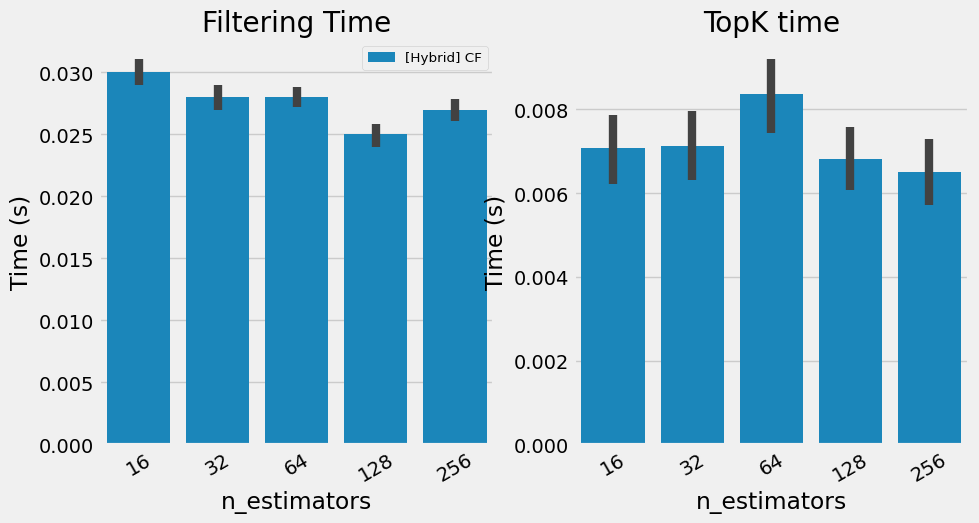

In [5]:
parameter_tuning("n_estimators", [16, 32, 64, 128, 256], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Minimum samples required to split
min_samples_split (int or float, default 10) – The minimum number of samples required to split an internal node:

If int, then consider min_samples_split as the minimum number.

If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split.

100%|██████████| 3/3 [00:26<00:00,  8.81s/it]


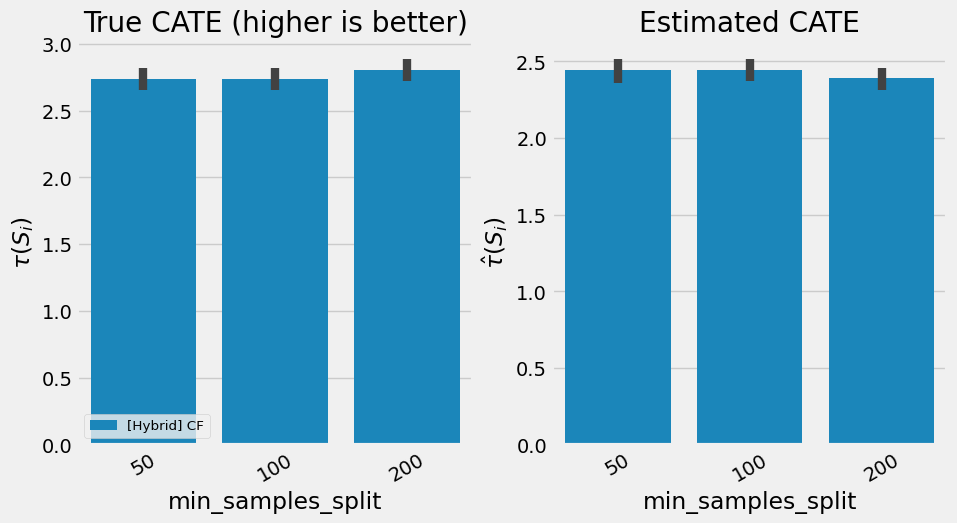

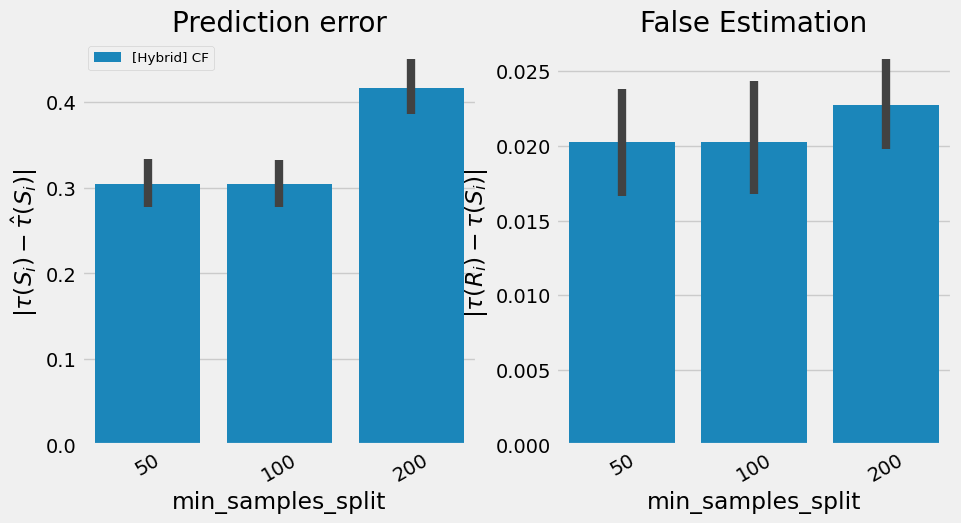

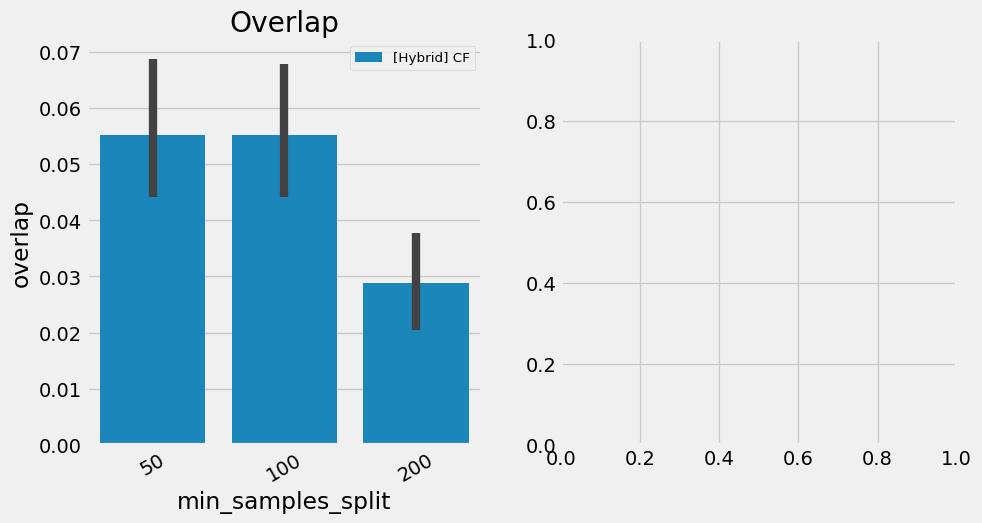

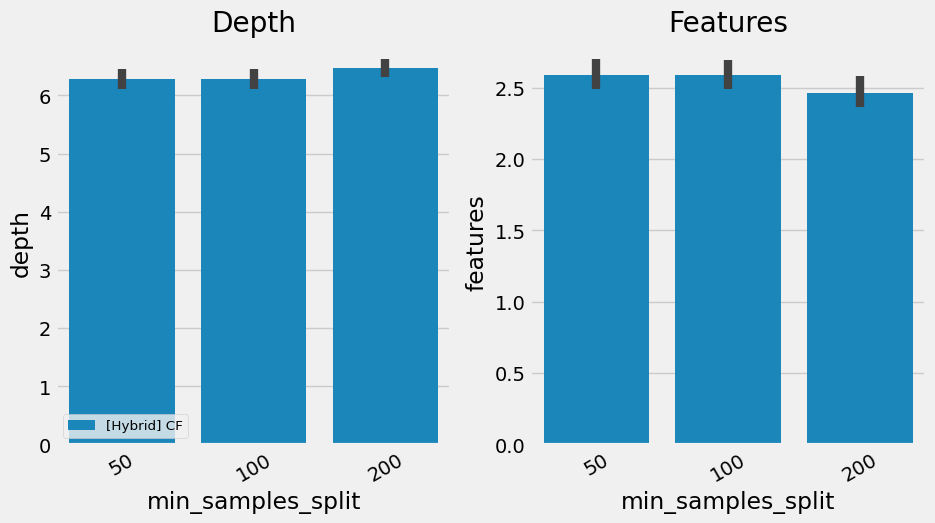

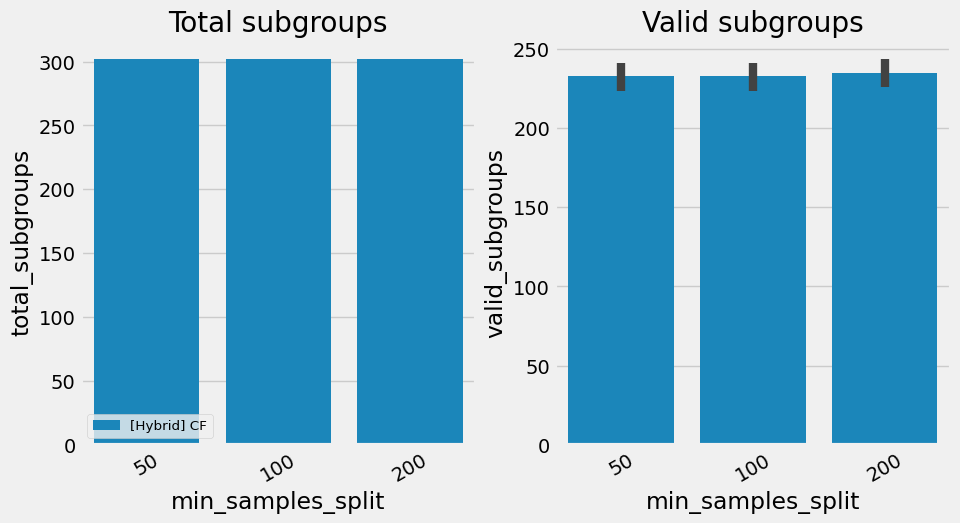

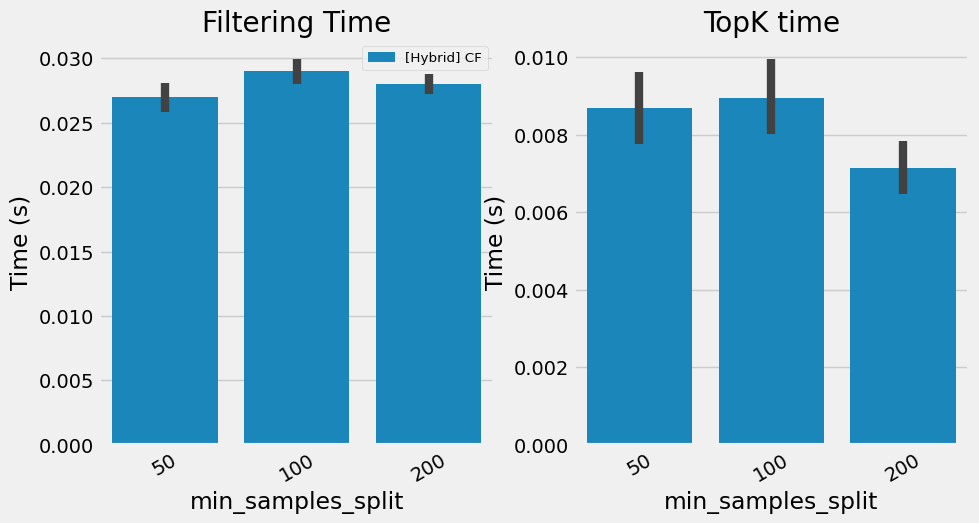

In [6]:
parameter_tuning("min_samples_split", [50, 100, 200], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Minimum samples required at a leaf node
min_samples_leaf (int or float, default 5) – The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number.

If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.


100%|██████████| 5/5 [01:53<00:00, 22.62s/it]


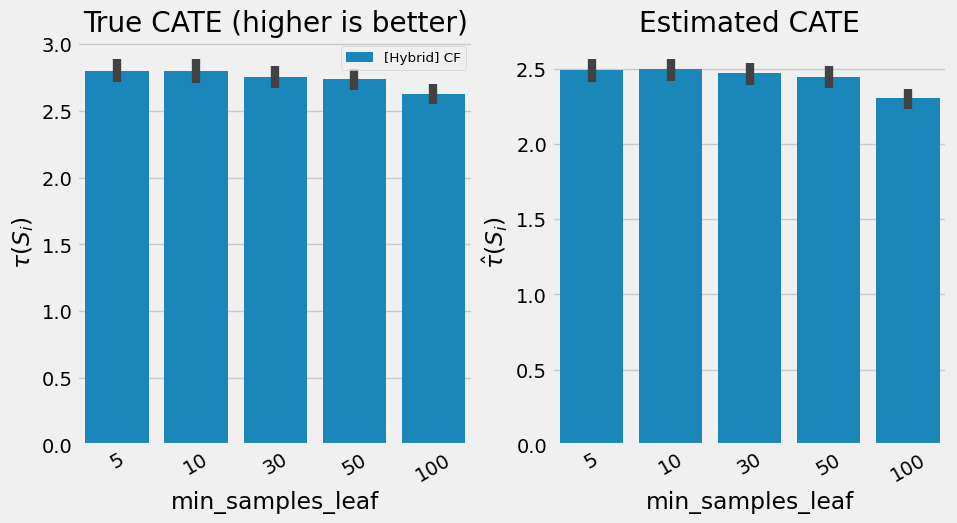

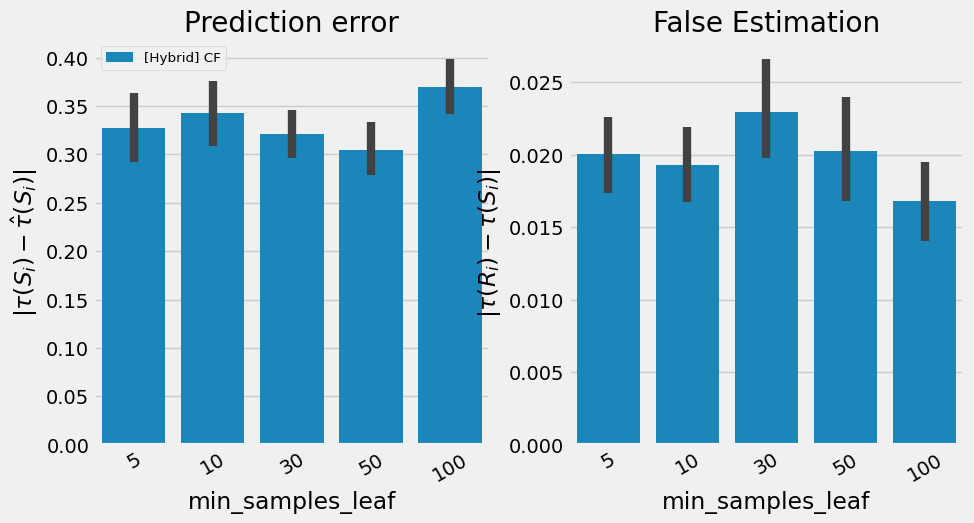

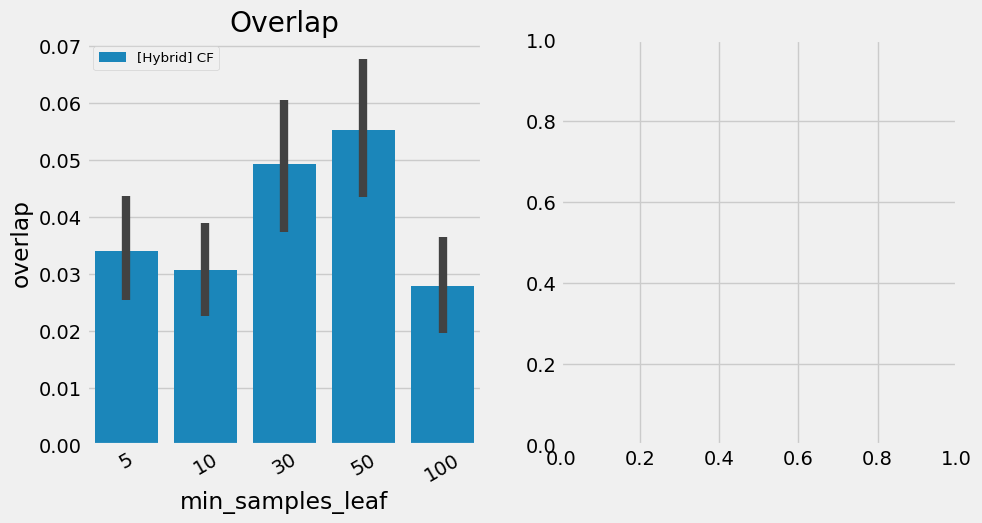

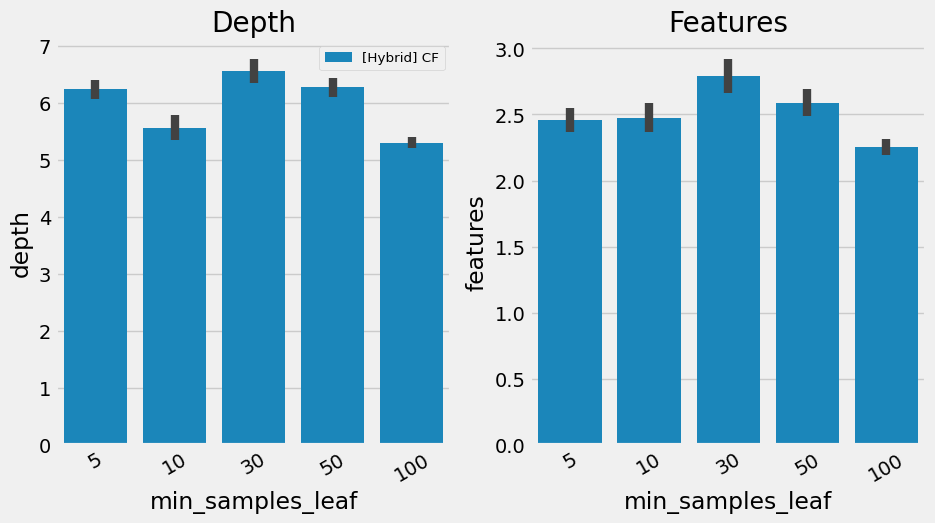

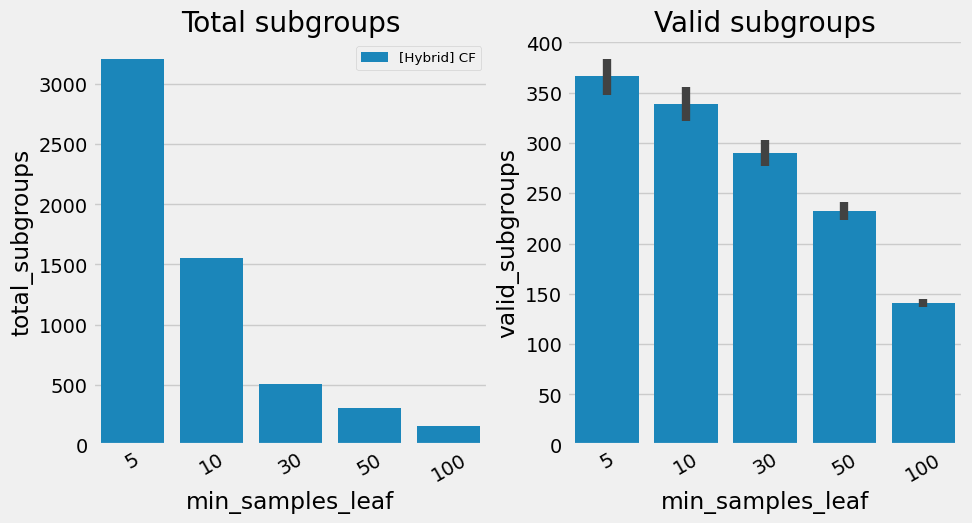

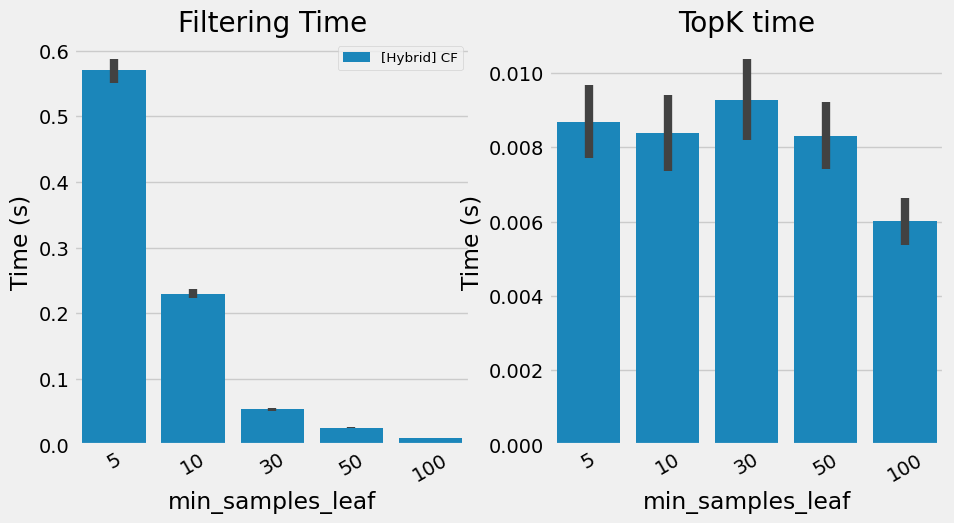

In [7]:
parameter_tuning("min_samples_leaf", [5, 10, 30, 50, 100], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Maximum tree depth
max_depth (int, default None)

If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.

100%|██████████| 6/6 [10:38<00:00, 106.37s/it]


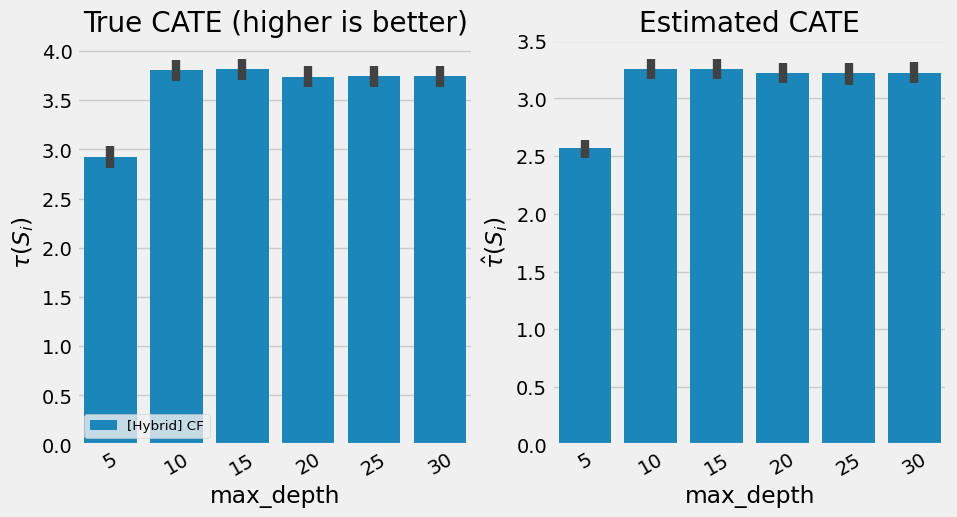

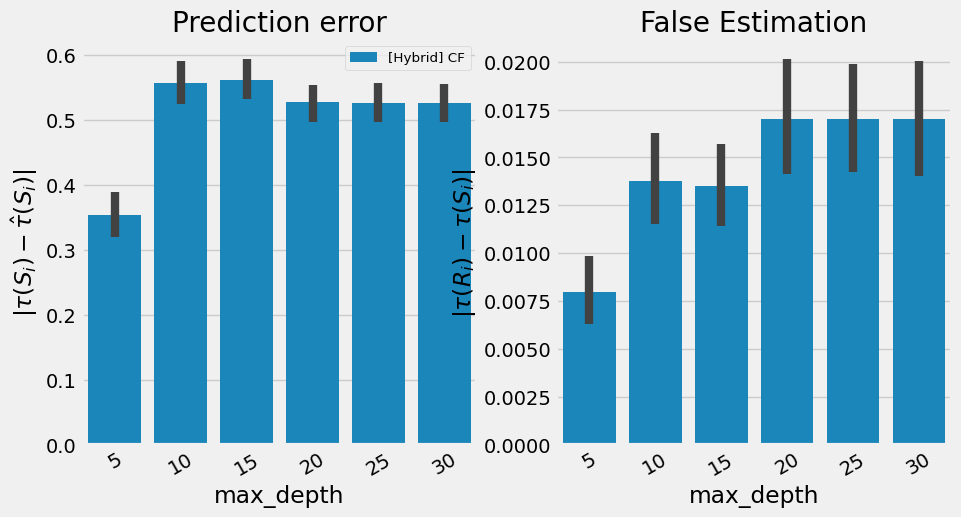

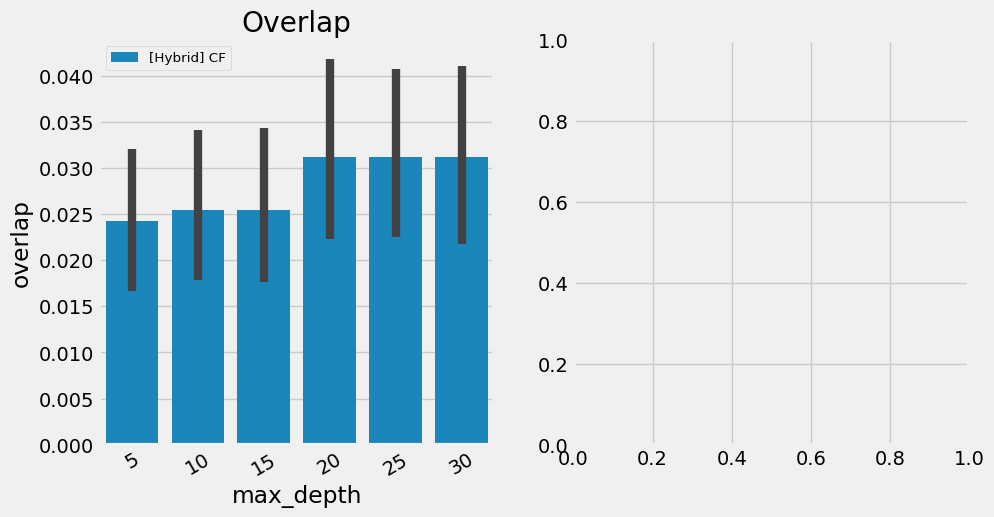

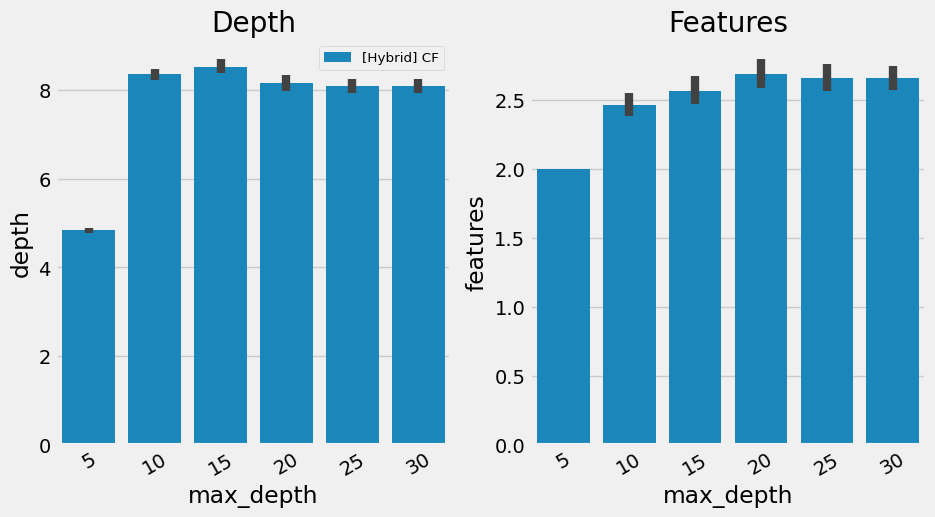

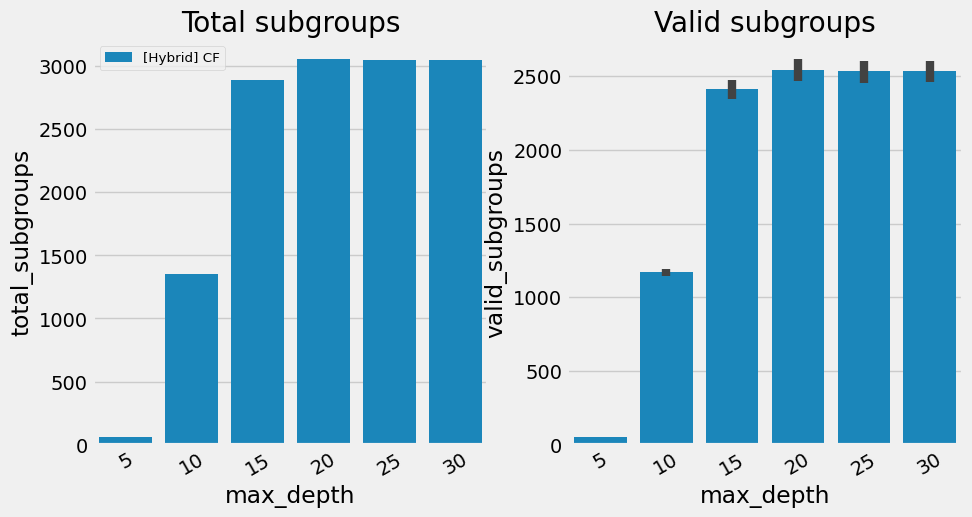

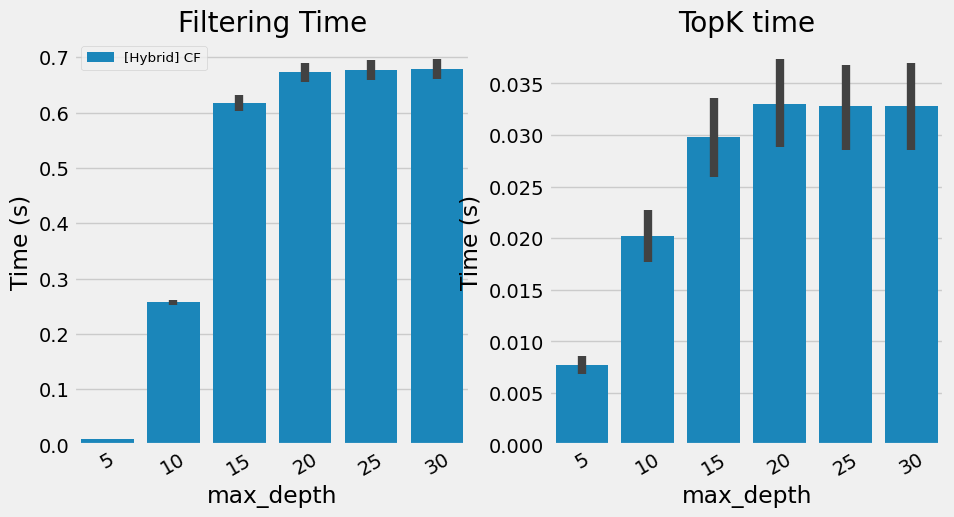

In [6]:
parameter_tuning("max_depth", [5, 10, 15, 20, 25, 30], data_iterations=1, user_iterations=10, scanners = main_competitors)

# Maximum features to consider for split
max_features : int, float, {"auto", "sqrt", "log2"}, or None, default None

The number of features to consider when looking for the best split:

- If int, then consider `max_features` features at each split.
- If float, then `max_features` is a fraction and `int(max_features * n_features)` features
    are considered at each split.
- If "auto", then `max_features=n_features`.
- If "sqrt", then `max_features=sqrt(n_features)`.
- If "log2", then `max_features=log2(n_features)`.
- If None, then `max_features=n_features`.

100%|██████████| 4/4 [00:34<00:00,  8.55s/it]


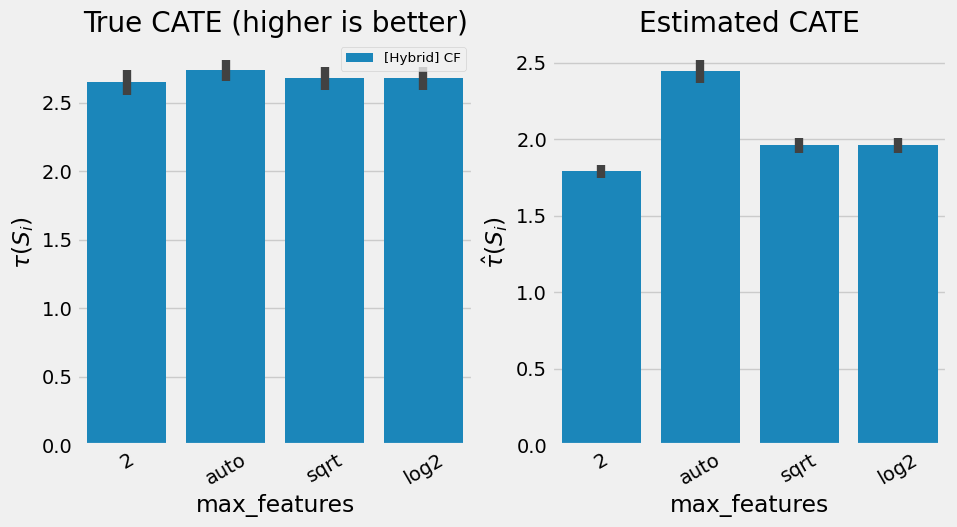

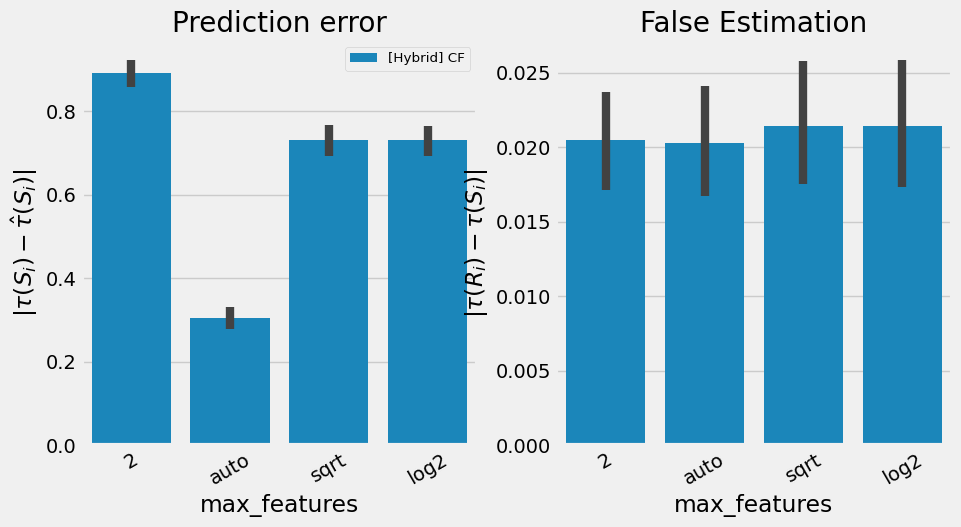

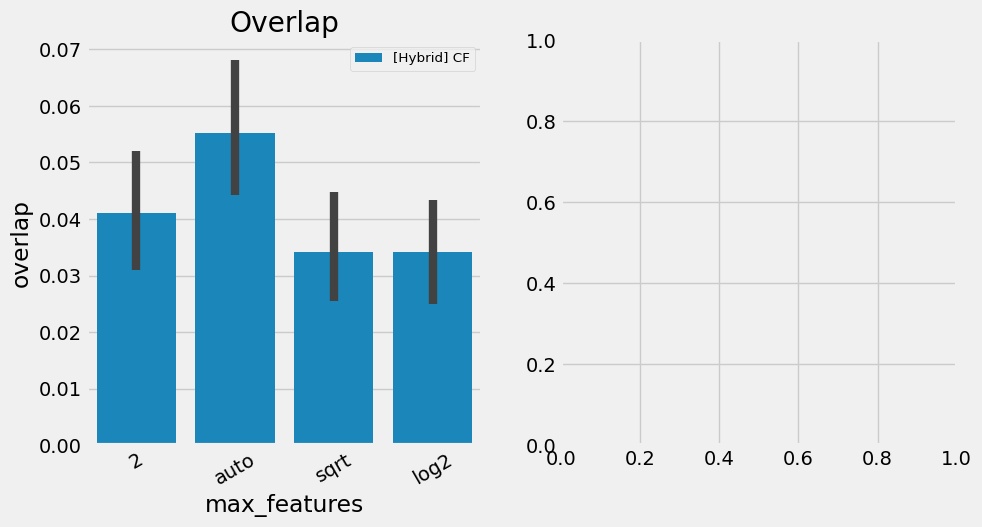

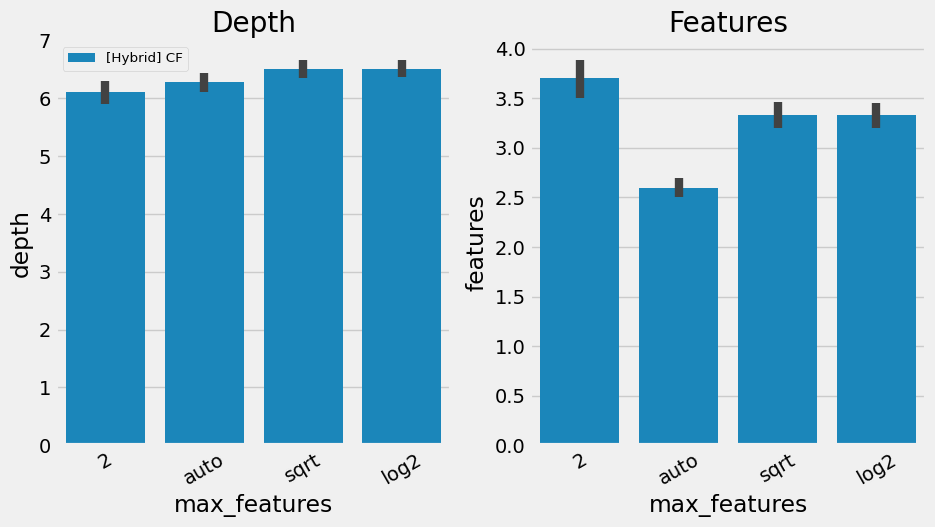

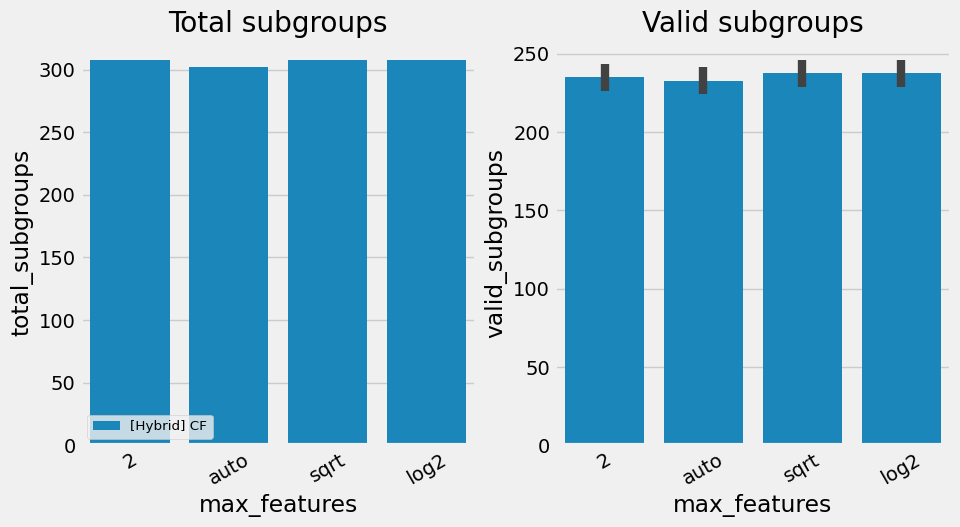

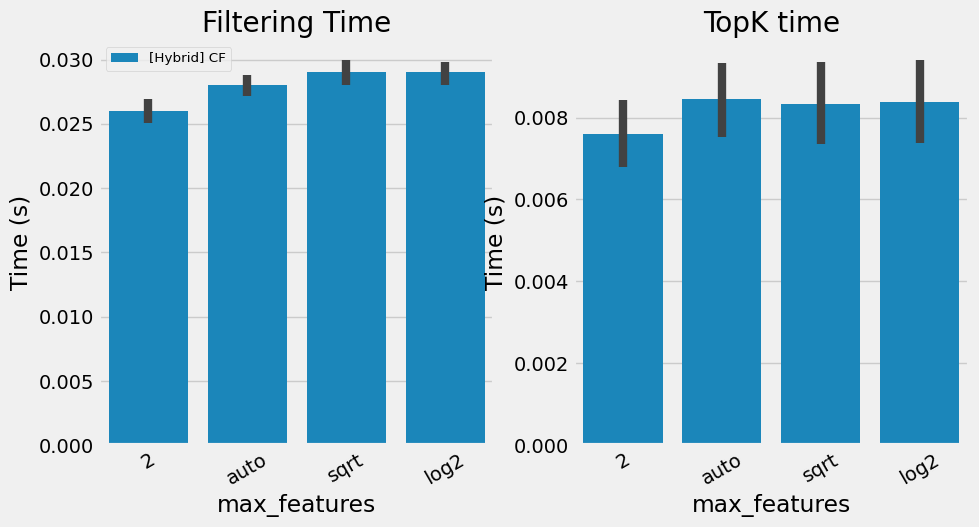

In [9]:
parameter_tuning("max_features", [2,'auto','sqrt','log2'], data_iterations=1, user_iterations=10, scanners = main_competitors)